## Script to visualize the DWD phenology data downloaded from: https://opendata.dwd.de/climate_environment/CDC/grids_germany/annual/phenology for Fagus Sylvatica.


## Packages

In [1]:
from functions.dwd_to_xarray import *
from functions.plot_functions import *

## Read DWD

In [2]:
dwd = dwd_to_xarray(r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\DWD\beech_raster_spring", r"C:\Users\miles\OneDrive\Dokumente\EAGLE SoSe\Linking science\DWD\beech_raster_fall")

## Calculate LOS

In [3]:
LOS = dwd.sel(band="EOS") - dwd.sel(band="SOS")
LOS = LOS.assign_coords(band="LOS").expand_dims('band')
dwd = xr.concat([dwd, LOS], dim='band')

#dwd.plot.hist(bins=100)

## Timeseries ridgeplot

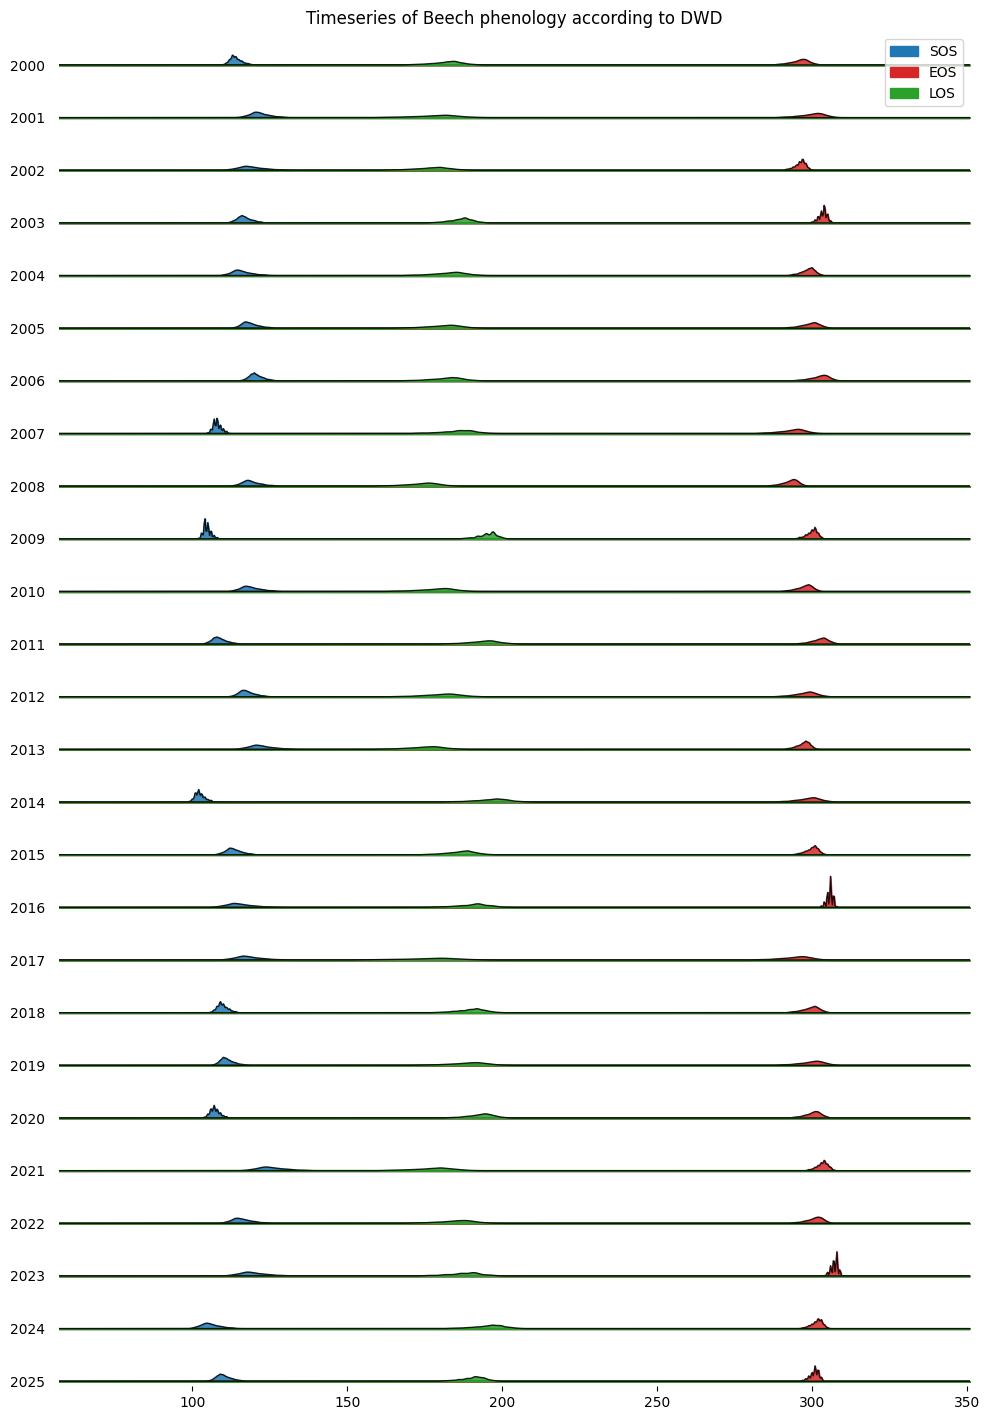

In [4]:
xarray_ridgeplot(dwd, bands =["SOS", "EOS", "LOS"], title="Timeseries of Beech phenology according to DWD")

## Get SRTM

## Scatterplot